# Data Exploratory 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import numpy as np

In [2]:
df = pd.read_csv("dataset_mood_smartphone.csv", sep=",").drop(columns=["Unnamed: 0"])
df.head()

,id,time,variable,value
0,AS14.01,2014-02-26 13:00:00.000,mood,6.0
1,AS14.01,2014-02-26 15:00:00.000,mood,6.0
2,AS14.01,2014-02-26 18:00:00.000,mood,6.0
3,AS14.01,2014-02-26 21:00:00.000,mood,7.0
4,AS14.01,2014-02-27 09:00:00.000,mood,6.0


In [3]:
VALID_RANGES = {
    "mood":                  (1, 10),
    "circumplex.arousal":    (-2, 2),
    "circumplex.valence":    (-2, 2),
    "activity":              (0, 1),
    "screen":                (0, None),      # non-negative
    "call":                  (0, None),
    "sms":                   (0, None),
}


In [4]:
print("=" * 60)
print("1. BASIC SHAPE")
print("=" * 60)
print(f"Total rows       : {len(df):,}")
print(f"Columns          : {df.columns.tolist()}")
print(f"Unique users     : {df['id'].nunique()}")
print(f"Unique variables : {df['variable'].nunique()}")
print(f"Variables        : {sorted(df['variable'].unique())}")
print(f"Date range       : {df['time'].min()}  →  {df['time'].max()}")
# print(f"Span (days)      : {(df['time'].max() - df['time'].min()).days}")

1. BASIC SHAPE
Total rows       : 376,912
Columns          : ['id', 'time', 'variable', 'value']
Unique users     : 27
Unique variables : 19
Variables        : ['activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'circumplex.arousal', 'circumplex.valence', 'mood', 'screen', 'sms']
Date range       : 2014-02-17 07:00:52.197  →  2014-06-09 00:00:00.000


In [5]:
print("=" * 60)
print("2. PER-VARIABLE STATISTICS")
print("=" * 60)
 
stats_rows = []
for var, grp in df.groupby("variable"):
    vals = grp["value"].dropna()
    lo, hi = VALID_RANGES.get(var, (0, None))
    out_of_range = (vals < lo).sum() if lo is not None else 0
    if hi is not None:
        out_of_range += (vals > hi).sum()
    stats_rows.append({
        "variable":      var,
        "count":         len(vals),
        "missing":       grp["value"].isna().sum(),
        "mean":          round(vals.mean(), 3),
        "std":           round(vals.std(), 3),
        "min":           round(vals.min(), 3),
        "max":           round(vals.max(), 3),
        "skewness":      round(vals.skew(), 3),
        "out_of_range":  out_of_range,
    })
 
stats_df = pd.DataFrame(stats_rows).set_index("variable")
print(stats_df.to_string())
print()


2. PER-VARIABLE STATISTICS
                      count  missing     mean      std        min        max  skewness  out_of_range
variable                                                                                            
activity              22965        0    0.116    0.187      0.000      1.000     2.090             0
appCat.builtin        91288        0   18.538  415.989 -82798.871  33960.246       NaN             3
appCat.communication  74276        0   43.344  128.913      0.006   9830.777     0.000             0
appCat.entertainment  27125        0   37.576  262.960     -0.011  32148.677    78.067             1
appCat.finance          939        0   21.755   39.218      0.131    355.513     4.236             0
appCat.game             813        0  128.392  327.145      1.003   5491.793     9.691             0
appCat.office          5642        0   22.579  449.601      0.003  32708.818    68.676             0
appCat.other           7650        0   25.811  112.781      0.01

In [6]:
list(df['variable'].unique())

['mood',
 'circumplex.arousal',
 'circumplex.valence',
 'activity',
 'screen',
 'call',
 'sms',
 'appCat.builtin',
 'appCat.communication',
 'appCat.entertainment',
 'appCat.finance',
 'appCat.game',
 'appCat.office',
 'appCat.other',
 'appCat.social',
 'appCat.travel',
 'appCat.unknown',
 'appCat.utilities',
 'appCat.weather']

## Task 1B: Data Cleaning

In [7]:
df["date"] = pd.to_datetime(df["time"]).dt.date
df.head()

,id,time,variable,value,date
0,AS14.01,2014-02-26 13:00:00.000,mood,6.0,2014-02-26
1,AS14.01,2014-02-26 15:00:00.000,mood,6.0,2014-02-26
2,AS14.01,2014-02-26 18:00:00.000,mood,6.0,2014-02-26
3,AS14.01,2014-02-26 21:00:00.000,mood,7.0,2014-02-26
4,AS14.01,2014-02-27 09:00:00.000,mood,6.0,2014-02-27


In [8]:
def remove_invalid_values(df):
    df = df.copy()
    initial_rows = len(df)

    removal_stats = {}

    # Initialize all variables in stats
    for var in df["variable"].unique():
        removal_stats[var] = 0

    keep_mask = pd.Series(True, index=df.index)

    # ---- RULE-BASED VALIDATION ----
    rules = {
        "mood": (df["value"] >= 1) & (df["value"] <= 10),
        "circumplex.arousal": (df["value"] >= -2) & (df["value"] <= 2),
        "circumplex.valence": (df["value"] >= -2) & (df["value"] <= 2),
        "activity": (df["value"] >= 0) & (df["value"] <= 1),
        "call": df["value"].isin([0, 1]),
        "sms": df["value"].isin([0, 1]),
    }

    for var, rule in rules.items():
        mask = (df["variable"] == var)
        invalid = mask & ~rule
        removal_stats[var] += invalid.sum()
        keep_mask &= ~invalid

    # ---- DURATION VARIABLES ----
    usage_mask = df["variable"].str.startswith("appCat.") | (df["variable"] == "screen")
    invalid_usage = usage_mask & ((df["value"] < 0) | (df["value"] > 86400))

    for var in df.loc[usage_mask, "variable"].unique():
        var_invalid = (df["variable"] == var) & ((df["value"] < 0) | (df["value"] > 86400))
        removal_stats[var] += var_invalid.sum()

    keep_mask &= ~invalid_usage

    # ---- FINAL FILTER ----
    removed_df = df.loc[~keep_mask].copy()
    df_clean = df.loc[keep_mask].copy()

    print(f"Rows before: {initial_rows}, after: {len(df_clean)}")
    
    return df_clean, removed_df, removal_stats


clean_df, removed_df, removal_stats = remove_invalid_values(df)
print("\nRemoved values per variable:")
for var in sorted(removal_stats.keys()):
    print(f"{var:25s}: {removal_stats[var]}")

Rows before: 376912, after: 376706

Removed values per variable:
activity                 : 0
appCat.builtin           : 3
appCat.communication     : 0
appCat.entertainment     : 1
appCat.finance           : 0
appCat.game              : 0
appCat.office            : 0
appCat.other             : 0
appCat.social            : 0
appCat.travel            : 0
appCat.unknown           : 0
appCat.utilities         : 0
appCat.weather           : 0
call                     : 0
circumplex.arousal       : 46
circumplex.valence       : 156
mood                     : 0
screen                   : 0
sms                      : 0


In [ ]:
# def iqr_winsorize(df):
#     df = df.copy()
#     stats = []

#     if "variable" not in df.columns:
#         raise KeyError("The input dataframe must contain a 'variable' column.")

#     processed_groups = []
#     for var, group in df.groupby("variable", sort=False):
#         group = group.copy()

#         Q1 = group["value"].quantile(0.25)
#         Q3 = group["value"].quantile(0.75)
#         IQR = Q3 - Q1

#         lower = Q1 - 1.5 * IQR
#         upper = Q3 + 1.5 * IQR

#         # Domain constraint for duration variables
#         if var.startswith("appCat") or var == "screen":
#             lower = max(lower, 0)

#         before = group["value"]
#         after = before.clip(lower, upper)

#         num_outliers = ((before < lower) | (before > upper)).sum()
#         num_clipped = (before != after).sum()

#         stats.append({
#             "variable": var,
#             "lower": lower,
#             "upper": upper,
#             "outliers_detected": int(num_outliers),
#             "values_clipped": int(num_clipped)
#         })

#         group["value"] = after
#         processed_groups.append(group)

#     df = pd.concat(processed_groups, axis=0).sort_index()
#     stats_df = pd.DataFrame(stats)
#     return df, stats_df


# clean_df, iqr_stats = iqr_winsorize(clean_df)

# print("\nIQR Stats:")
# display(iqr_stats)

In [9]:
def aggregate_daily(df):
    df = df.copy()

    # Convert time → datetime
    df["time"] = pd.to_datetime(df["time"])

    # Extract date
    df["date"] = df["time"].dt.date

    mean_vars = ["mood", "activity", "circumplex.arousal", "circumplex.valence"]

    df_mean = df[df["variable"].isin(mean_vars)].pivot_table(
        index=["id", "date"],
        columns="variable",
        values="value",
        aggfunc="mean"
    )

    df_sum = df[~df["variable"].isin(mean_vars)].pivot_table(
        index=["id", "date"],
        columns="variable",
        values="value",
        aggfunc="sum"
    )

    df_daily = pd.concat([df_mean, df_sum], axis=1).reset_index()

    return df_daily

df_daily = aggregate_daily(clean_df)

duration_vars = [col for col in df_daily.columns if "appCat" in col or col in ["screen", "call", "sms"]]

df_daily[duration_vars] = df_daily[duration_vars].fillna(0)

print(f"Daily aggregated shape: {df_daily.shape}")
df_daily.head()

Daily aggregated shape: (1973, 21)


variable,id,date,activity,circumplex.arousal,circumplex.valence,mood,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,...,appCat.office,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,screen,sms
0,AS14.01,2014-02-26,NaN,-0.25,0.750000,6.250000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,1.0,0.000,2.0
1,AS14.01,2014-02-27,NaN,0.00,0.333333,6.333333,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.0
2,AS14.01,2014-03-20,0.081548,NaN,NaN,NaN,248.979,2168.229,350.856,0.000,...,0.000,11.345,807.731,0.000,45.173,21.074,0.0,1.0,2275.944,0.0
3,AS14.01,2014-03-21,0.134050,0.20,0.200000,6.200000,3139.218,6280.890,1007.456,49.544,...,172.206,239.751,4508.500,915.445,0.000,598.754,0.0,6.0,17978.907,0.0
4,AS14.01,2014-03-22,0.236880,0.60,0.500000,6.400000,731.429,4962.918,93.324,21.076,...,0.000,98.143,439.632,37.305,0.000,117.621,0.0,3.0,6142.161,1.0


In [10]:
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.sort_values(['id', 'date']).set_index(['id', 'date'])
display(df_daily.head())
display(df_daily.tail())

variable            activity  circumplex.arousal  circumplex.valence  mood  \
id      date                                                                 
AS14.01 2014-02-17       NaN                 NaN                 NaN   NaN   
        2014-02-18       NaN                 NaN                 NaN   NaN   
        2014-02-19       NaN                 NaN                 NaN   NaN   
        2014-02-20       NaN                 NaN                 NaN   NaN   
        2014-02-21       NaN                 NaN                 NaN   NaN   

variable            appCat.builtin  appCat.communication  \
id      date                                               
AS14.01 2014-02-17             0.0                   0.0   
        2014-02-18             0.0                   0.0   
        2014-02-19             0.0                   0.0   
        2014-02-20             0.0                   0.0   
        2014-02-21             0.0                   0.0   

variable            appCat.entertainment  appCat.finance  appCat.game  \
id      date                                                            
AS14.01 2014-02-17                   0.0             0.0          0.0   
        2014-02-18                   0.0             0.0          0.0   
        2014-02-19                   0.0             0.0          0.0   
        2014-02-20                   0.0             0.0          0.0   
        2014-02-21                   0.0             0.0          0.0   

variable            appCat.office  appCat.other  appCat.social  appCat.travel  \
id      date                                                                    
AS14.01 2014-02-17            0.0           0.0            0.0            0.0   
        2014-02-18            0.0           0.0            0.0            0.0   
        2014-02-19            0.0           0.0            0.0            0.0   
        2014-02-20            0.0           0.0            0.0            0.0   
        2014-02-21            0.0           0.0            0.0            0.0   

variable            appCat.unknown  appCat.utilities  appCat.weather  call  \
id      date                                                                 
AS14.01 2014-02-17             0.0               0.0             0.0   2.0   
        2014-02-18             0.0               0.0             0.0   1.0   
        2014-02-19             0.0               0.0             0.0   7.0   
        2014-02-20             0.0               0.0             0.0   2.0   
        2014-02-21             0.0               0.0             0.0   0.0   

variable            screen  sms  
id      date                     
AS14.01 2014-02-17     0.0  0.0  
        2014-02-18     0.0  0.0  
        2014-02-19     0.0  2.0  
        2014-02-20     0.0  3.0  
        2014-02-21     0.0  1.0

variable            activity  circumplex.arousal  circumplex.valence  mood  \
id      date                                                                 
AS14.33 2014-05-27  0.012704           -0.600000                 0.4   6.2   
        2014-05-28  0.103301            0.000000                 1.2   8.2   
        2014-05-29  0.169354           -1.333333                 1.0   7.0   
        2014-05-30  0.192901           -0.800000                -0.4   6.8   
        2014-05-31       NaN           -2.000000                 1.0   7.0   

variable            appCat.builtin  appCat.communication  \
id      date                                               
AS14.33 2014-05-27         726.391              2078.403   
        2014-05-28        2551.046              1936.415   
        2014-05-29         400.034               435.105   
        2014-05-30        3044.030              1670.842   
        2014-05-31           0.000                 0.000   

variable            appCat.entertainment  appCat.finance  appCat.game  \
id      date                                                            
AS14.33 2014-05-27               124.694             0.0          0.0   
        2014-05-28               614.706             0.0          0.0   
        2014-05-29               136.738             0.0          0.0   
        2014-05-30               260.220             0.0          0.0   
        2014-05-31                 0.000             0.0          0.0   

variable            appCat.office  appCat.other  appCat.social  appCat.travel  \
id      date                                                                    
AS14.33 2014-05-27          0.000       142.686       2010.364          0.000   
        2014-05-28        357.909       529.946       5361.211          0.000   
        2014-05-29          0.000        29.202       1789.922          0.939   
        2014-05-30          0.000        52.610       3166.409       1052.648   
        2014-05-31          0.000         0.000          0.000          0.000   

variable            appCat.unknown  appCat.utilities  appCat.weather  call  \
id      date                                                                 
AS14.33 2014-05-27           0.000            56.173             0.0   1.0   
        2014-05-28           0.000            30.666             0.0  10.0   
        2014-05-29           0.000             3.199             0.0   5.0   
        2014-05-30           8.072           232.825             0.0   4.0   
        2014-05-31           0.000             0.000             0.0   0.0   

variable                  screen  sms  
id      date                           
AS14.33 2014-05-27   4089.879001  2.0  
        2014-05-28  14320.867998  1.0  
        2014-05-29   3569.341000  1.0  
        2014-05-30   9497.646999  0.0  
        2014-05-31      0.000000  0.0

In [12]:
def make_complete_panel(df):
    full = []

    for user_id, group in df.groupby(level=0):
        idx = pd.date_range(
            start=group.index.get_level_values(1).min(),
            end=group.index.get_level_values(1).max(),
            freq='D'
        )
        group = group.droplevel(0)
        group = group.reindex(idx)
        group['id'] = user_id
        group.index.name = 'date'
        group = group.reset_index().set_index(['id', 'date'])
        full.append(group)

    return pd.concat(full)

df_panel = make_complete_panel(df_daily).sort_index()
print(f"Complete panel shape: {df_panel.shape}")
display(df_panel.head())

Complete panel shape: (2154, 19)


variable            activity  circumplex.arousal  circumplex.valence  mood  \
id      date                                                                 
AS14.01 2014-02-17       NaN                 NaN                 NaN   NaN   
        2014-02-18       NaN                 NaN                 NaN   NaN   
        2014-02-19       NaN                 NaN                 NaN   NaN   
        2014-02-20       NaN                 NaN                 NaN   NaN   
        2014-02-21       NaN                 NaN                 NaN   NaN   

variable            appCat.builtin  appCat.communication  \
id      date                                               
AS14.01 2014-02-17             0.0                   0.0   
        2014-02-18             0.0                   0.0   
        2014-02-19             0.0                   0.0   
        2014-02-20             0.0                   0.0   
        2014-02-21             0.0                   0.0   

variable            appCat.entertainment  appCat.finance  appCat.game  \
id      date                                                            
AS14.01 2014-02-17                   0.0             0.0          0.0   
        2014-02-18                   0.0             0.0          0.0   
        2014-02-19                   0.0             0.0          0.0   
        2014-02-20                   0.0             0.0          0.0   
        2014-02-21                   0.0             0.0          0.0   

variable            appCat.office  appCat.other  appCat.social  appCat.travel  \
id      date                                                                    
AS14.01 2014-02-17            0.0           0.0            0.0            0.0   
        2014-02-18            0.0           0.0            0.0            0.0   
        2014-02-19            0.0           0.0            0.0            0.0   
        2014-02-20            0.0           0.0            0.0            0.0   
        2014-02-21            0.0           0.0            0.0            0.0   

variable            appCat.unknown  appCat.utilities  appCat.weather  call  \
id      date                                                                 
AS14.01 2014-02-17             0.0               0.0             0.0   2.0   
        2014-02-18             0.0               0.0             0.0   1.0   
        2014-02-19             0.0               0.0             0.0   7.0   
        2014-02-20             0.0               0.0             0.0   2.0   
        2014-02-21             0.0               0.0             0.0   0.0   

variable            screen  sms  
id      date                     
AS14.01 2014-02-17     0.0  0.0  
        2014-02-18     0.0  0.0  
        2014-02-19     0.0  2.0  
        2014-02-20     0.0  3.0  
        2014-02-21     0.0  1.0

In [14]:
missing_flags = df_panel.isna().astype(int)
missing_flags.columns = [c + "_was_missing" for c in df_panel.columns]

df_panel = pd.concat([df_panel, missing_flags], axis=1)
display(df_panel.head())

activity  circumplex.arousal  circumplex.valence  mood  \
id      date                                                                 
AS14.01 2014-02-17       NaN                 NaN                 NaN   NaN   
        2014-02-18       NaN                 NaN                 NaN   NaN   
        2014-02-19       NaN                 NaN                 NaN   NaN   
        2014-02-20       NaN                 NaN                 NaN   NaN   
        2014-02-21       NaN                 NaN                 NaN   NaN   

                    appCat.builtin  appCat.communication  \
id      date                                               
AS14.01 2014-02-17             0.0                   0.0   
        2014-02-18             0.0                   0.0   
        2014-02-19             0.0                   0.0   
        2014-02-20             0.0                   0.0   
        2014-02-21             0.0                   0.0   

                    appCat.entertainment  appCat.finance  appCat.game  \
id      date                                                            
AS14.01 2014-02-17                   0.0             0.0          0.0   
        2014-02-18                   0.0             0.0          0.0   
        2014-02-19                   0.0             0.0          0.0   
        2014-02-20                   0.0             0.0          0.0   
        2014-02-21                   0.0             0.0          0.0   

                    appCat.office  ...  appCat.office_was_missing  \
id      date                       ...                              
AS14.01 2014-02-17            0.0  ...                          0   
        2014-02-18            0.0  ...                          0   
        2014-02-19            0.0  ...                          0   
        2014-02-20            0.0  ...                          0   
        2014-02-21            0.0  ...                          0   

                    appCat.other_was_missing  appCat.social_was_missing  \
id      date                                                              
AS14.01 2014-02-17                         0                          0   
        2014-02-18                         0                          0   
        2014-02-19                         0                          0   
        2014-02-20                         0                          0   
        2014-02-21                         0                          0   

                    appCat.travel_was_missing  appCat.unknown_was_missing  \
id      date                                                                
AS14.01 2014-02-17                          0                           0   
        2014-02-18                          0                           0   
        2014-02-19                          0                           0   
        2014-02-20                          0                           0   
        2014-02-21                          0                           0   

                    appCat.utilities_was_missing  appCat.weather_was_missing  \
id      date                                                                   
AS14.01 2014-02-17                             0                           0   
        2014-02-18                             0                           0   
        2014-02-19                             0                           0   
        2014-02-20                             0                           0   
        2014-02-21                             0                           0   

                    call_was_missing  screen_was_missing  sms_was_missing  
id      date                                                               
AS14.01 2014-02-17                 0                   0                0  
        2014-02-18                 0                   0                0  
        2014-02-19                 0                   0                0  
        2014-02-20                 0             

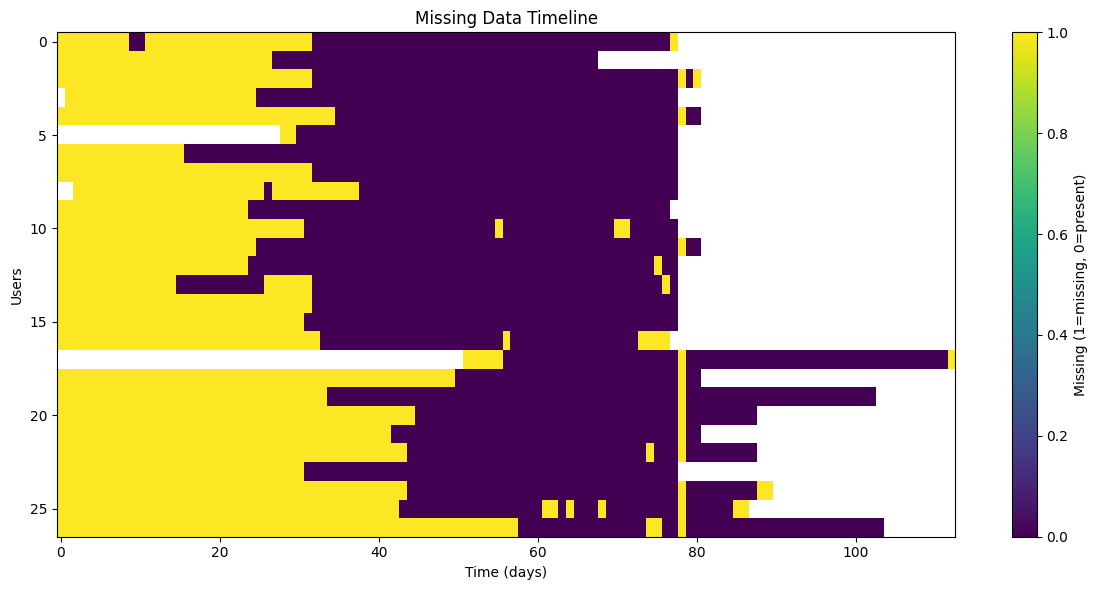

In [15]:
missing_matrix = df_panel["mood"].isna().unstack(level=0).T.astype(float)
missing_array = np.ma.masked_invalid(missing_matrix.values)

plt.figure(figsize=(12, 6))
plt.imshow(missing_array, aspect="auto", interpolation="none", cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Missing (1=missing, 0=present)")
plt.title("Missing Data Timeline")
plt.xlabel("Time (days)")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


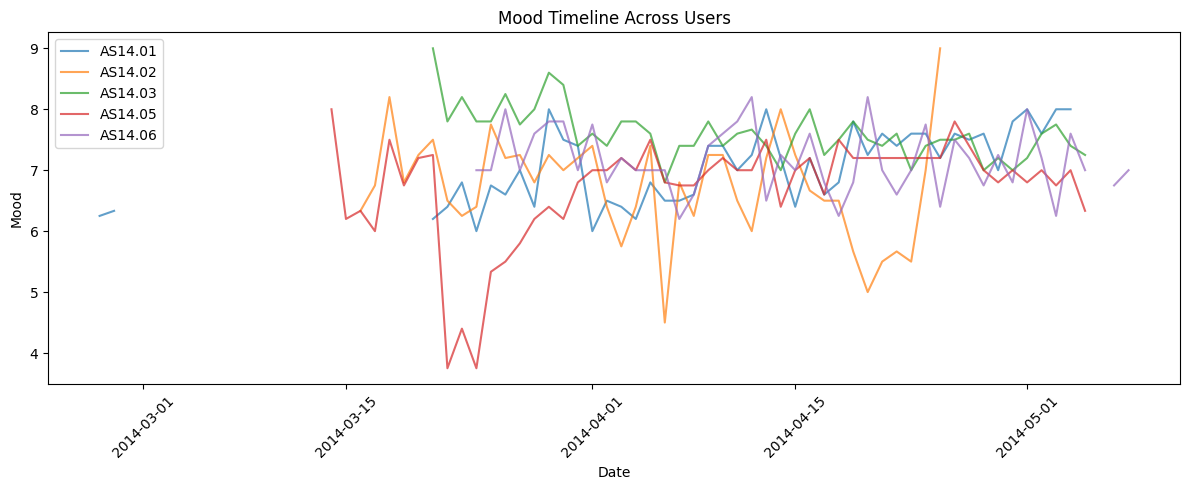

In [16]:
df_panel = df_panel.sort_index()

plt.figure(figsize=(12, 5))

for user in df_panel.index.get_level_values(0).unique()[:5]:  # limit to 5 users for clarity
    user_df = df_panel.loc[user]
    plt.plot(user_df.index, user_df["mood"], alpha=0.7, label=user)

plt.title("Mood Timeline Across Users")
plt.xlabel("Date")
plt.ylabel("Mood")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
key_cols = ["mood", "activity", "circumplex.arousal", "circumplex.valence"]  # adjust based on your dataset

df_panel["is_missing_day"] = df_panel[key_cols].isna().all(axis=1)

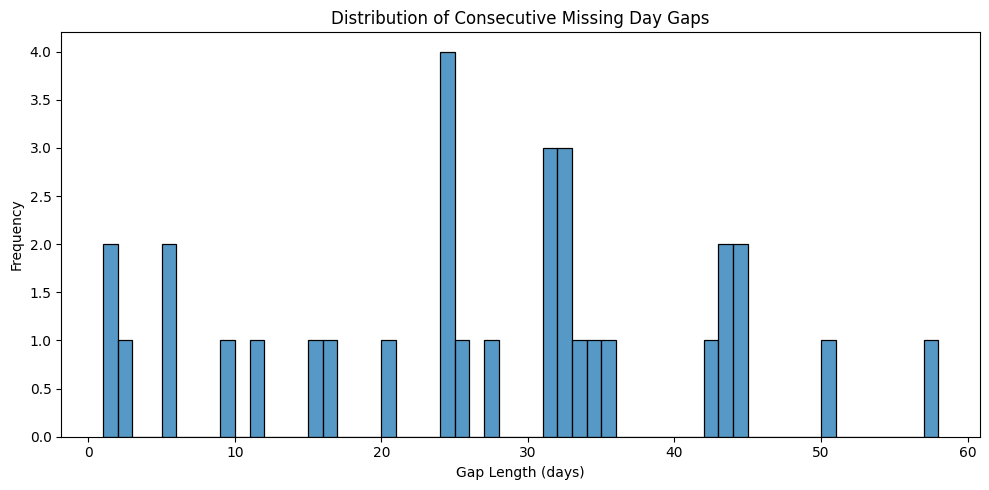

In [21]:
def compute_gap_lengths(group):
    missing = group["is_missing_day"].values

    gaps = []
    count = 0

    for m in missing:
        if m:
            count += 1
        else:
            if count > 0:
                gaps.append(count)
            count = 0

    if count > 0:
        gaps.append(count)

    return gaps

gap_lengths = df_panel.groupby(level=0).apply(compute_gap_lengths)
all_gaps = [gap for sublist in gap_lengths for gap in sublist]
plt.figure(figsize=(10, 5))
sns.histplot(all_gaps, bins=range(1, max(all_gaps) + 1), kde=False)
plt.title("Distribution of Consecutive Missing Day Gaps")
plt.xlabel("Gap Length (days)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [22]:
threshold = 3

big_gaps = [g for g in all_gaps if g > threshold]

print("Total gaps:", len(all_gaps))
print("Big gaps (>3 days):", len(big_gaps))
print("Max gap length:", max(all_gaps))

Total gaps: 32
Big gaps (>3 days): 29
Max gap length: 58


In [23]:
df_panel.groupby(level=0)["is_missing_day"].mean()


id
AS14.01    0.371795
AS14.02    0.397059
AS14.03    0.395062
AS14.05    0.311688
AS14.06    0.432099
AS14.07    0.040000
AS14.08    0.205128
AS14.09    0.410256
AS14.12    0.460526
AS14.13    0.311688
AS14.14    0.397436
AS14.15    0.308642
AS14.16    0.307692
AS14.17    0.256410
AS14.19    0.410256
AS14.20    0.397436
AS14.23    0.428571
AS14.24    0.080645
AS14.25    0.617284
AS14.26    0.330097
AS14.27    0.500000
AS14.28    0.518519
AS14.29    0.500000
AS14.30    0.397436
AS14.31    0.500000
AS14.32    0.494253
AS14.33    0.557692
Name: is_missing_day, dtype: float64

In [26]:
df_interp = df_panel.groupby(level=0, group_keys=False).apply(
    lambda x: x.interpolate(limit=3, limit_direction='both')
)

df_final = df_interp.groupby(level=0).transform(lambda x: x.fillna(x.mean()))

print("Final dataset shape:", df_final.shape)
display(df_final.head())


Final dataset shape: (2154, 39)


activity  circumplex.arousal  circumplex.valence  \
id      date                                                           
AS14.01 2014-02-17  0.089929           -0.211988            0.662865   
        2014-02-18  0.089929           -0.211988            0.662865   
        2014-02-19  0.089929           -0.211988            0.662865   
        2014-02-20  0.089929           -0.211988            0.662865   
        2014-02-21  0.089929           -0.211988            0.662865   

                        mood  appCat.builtin  appCat.communication  \
id      date                                                         
AS14.01 2014-02-17  6.952339             0.0                   0.0   
        2014-02-18  6.952339             0.0                   0.0   
        2014-02-19  6.952339             0.0                   0.0   
        2014-02-20  6.952339             0.0                   0.0   
        2014-02-21  6.952339             0.0                   0.0   

                    appCat.entertainment  appCat.finance  appCat.game  \
id      date                                                            
AS14.01 2014-02-17                   0.0             0.0          0.0   
        2014-02-18                   0.0             0.0          0.0   
        2014-02-19                   0.0             0.0          0.0   
        2014-02-20                   0.0             0.0          0.0   
        2014-02-21                   0.0             0.0          0.0   

                    appCat.office  ...  appCat.other_was_missing  \
id      date                       ...                             
AS14.01 2014-02-17            0.0  ...                         0   
        2014-02-18            0.0  ...                         0   
        2014-02-19            0.0  ...                         0   
        2014-02-20            0.0  ...                         0   
        2014-02-21            0.0  ...                         0   

                    appCat.social_was_missing  appCat.travel_was_missing  \
id      date                                                               
AS14.01 2014-02-17                          0                          0   
        2014-02-18                          0                          0   
        2014-02-19                          0                          0   
        2014-02-20                          0                          0   
        2014-02-21                          0                          0   

                    appCat.unknown_was_missing  appCat.utilities_was_missing  \
id      date                                                                   
AS14.01 2014-02-17                           0                             0   
        2014-02-18                           0                             0   
        2014-02-19                           0                             0   
        2014-02-20                           0                             0   
        2014-02-21                           0                             0   

                    appCat.weather_was_missing  call_was_missing  \
id      date                                                       
AS14.01 2014-02-17                           0                 0   
        2014-02-18                           0                 0   
        2014-02-19                           0                 0   
        2014-02-20                           0                 0   
        2014-02-21                           0                 0   

                    screen_was_missing  sms_was_missing  is_missing_day  
id      date                                                             
AS14.01 2014-02-17                   0                0            True  
        2014-02-18                   0                0            True  
        2014-02-19                   0                0            True  
        2014-02-20                   0                0            True  
        2014-02-21  

In [27]:
print("Remaining missing values:")
print(df_final.isna().sum().sort_values(ascending=False).head(20))

Remaining missing values:
activity                            0
appCat.other_was_missing            0
mood_was_missing                    0
appCat.builtin_was_missing          0
appCat.communication_was_missing    0
appCat.entertainment_was_missing    0
appCat.finance_was_missing          0
appCat.game_was_missing             0
appCat.office_was_missing           0
appCat.social_was_missing           0
circumplex.arousal_was_missing      0
appCat.travel_was_missing           0
appCat.unknown_was_missing          0
appCat.utilities_was_missing        0
appCat.weather_was_missing          0
call_was_missing                    0
screen_was_missing                  0
sms_was_missing                     0
circumplex.valence_was_missing      0
activity_was_missing                0
dtype: int64


In [28]:
print("Unique users:", df_final.index.get_level_values(0).nunique())
print("Date range:", df_final.index.get_level_values(1).min(), "→", df_final.index.get_level_values(1).max())

Unique users: 27
Date range: 2014-02-17 00:00:00 → 2014-06-09 00:00:00


In [30]:
before_na = df_panel.isna().sum().sum()
after_na = df_final.isna().sum().sum()

print("Before:", before_na)
print("After:", after_na)
print("Reduction:", before_na - after_na)

Before: 6341
After: 0
Reduction: 6341
